In [1]:
import os
import re
import csv
from collections import defaultdict
from statistics import mean

def parse_log_file_last_metrics(path):
    """从 log 文件末尾提取最后一次 eval 的指标"""
    eval_metrics = {}
    with open(path, encoding="utf-8") as f:
        lines = f.readlines()

    i = len(lines) - 1
    while i >= 0:
        if lines[i].strip().startswith("start to eval"):
            # hit20
            if i + 1 < len(lines) and lines[i+1].startswith("hit20"):
                m = re.search(r"hit20\s+([0-9.eE+-]+)", lines[i+1])
                if m:
                    eval_metrics["hit20"] = float(m.group(1))
            # hit50
            if i + 2 < len(lines) and lines[i+2].startswith("hit50"):
                m = re.search(r"hit50\s+([0-9.eE+-]+)", lines[i+2])
                if m:
                    eval_metrics["hit50"] = float(m.group(1))
            # hit100
            if i + 3 < len(lines) and lines[i+3].startswith("hit100"):
                m = re.search(r"hit100\s+([0-9.eE+-]+)", lines[i+3])
                if m:
                    eval_metrics["hit100"] = float(m.group(1))
            # 复合指标行
            if i + 4 < len(lines) and lines[i+4].startswith("roc_auc"):
                fields = ['roc_auc', 'pr_auc', 'f1', 'mrr']
                nums = [float(x) for x in re.findall(r'[-+]?\d*\.\d+|[-+]?\d+', lines[i+4])][-4:]
                result_dict = dict(zip(fields, nums))
                eval_metrics.update(result_dict)
            if eval_metrics:
                break
        i -= 1
    return eval_metrics


# ==== 用户指定参数 ====
dataset = "icews18"
ratios = [0.1, 0.4, 0.7, 0.9]
hs = [11, 13, 15, 17]
gammas = [3, 4, 5, 6]
alpha_list = [1, 5, 10, 15, 20, 30, 50, 80]
seeds = [1]  # 可扩展多 seed

log_base_dir = "."
output_dir = "./results"
os.makedirs(output_dir, exist_ok=True)

ALL_METRICS = ['hit20', 'hit50', 'hit100', 'roc_auc', 'pr_auc', 'f1', 'mrr']

# ==== 聚合结果 ====
metric_bucket = defaultdict(list)
metric_keys = set()

for seed in seeds:
    for ratio in ratios:
        for h in hs:
            for gamma in gammas:
                for alpha in alpha_list:
                    fname = f"r{ratio}-h{h}-g{gamma}-a{alpha}.log"
                    log_path = os.path.join(log_base_dir, fname)
                    key = (ratio, h, gamma, alpha)

                    if not os.path.isfile(log_path):
                        print(f"[WARN] 缺失: {log_path}")
                        metrics = {k: 0.0 for k in ALL_METRICS}
                        metric_bucket[key].append(metrics)
                        metric_keys.update(metrics.keys())
                        continue

                    metrics = parse_log_file_last_metrics(log_path)

                    if not metrics:
                        print(f"[WARN] 无 test 指标: {log_path}")
                        metrics = {k: 0.0 for k in ALL_METRICS}

                    metric_bucket[key].append(metrics)
                    metric_keys.update(metrics.keys())


# ==== 写入 CSV ====
csv_path = os.path.join(output_dir, f"{dataset}_grid_result.csv")
metric_keys = sorted(metric_keys)
header = ["split_ratio", "h", "gamma", "alpha"] + metric_keys

with open(csv_path, "w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=header)
    writer.writeheader()
    for key, metrics_list in metric_bucket.items():
        ratio, h, gamma, alpha = key
        row = {"split_ratio": ratio, "h": h, "gamma": gamma, "alpha": alpha}
        for k in metric_keys:
            vals = [m[k] for m in metrics_list if k in m]
            if vals:
                mu = round(round(mean(vals), 4) * 100, 2)
                row[k] = f"{mu}"
            else:
                row[k] = "0.0"
        writer.writerow(row)

print(f"[INFO] 写入完毕: {csv_path}")


[INFO] 写入完毕: ./results/icews18_grid_result.csv


In [2]:
import pandas as pd

# === 读取 CSV 结果 ===
csv_path = "./results/icews18_grid_result.csv"
df = pd.read_csv(csv_path)

# 将性能指标列转为 float
for col in ["roc_auc", "pr_auc", "f1"]:
    df[col] = df[col].astype(float)

# === 分组并检查单调性 ===
def is_monotonic_increasing(values):
    """判断是否严格/非严格单调递增"""
    vals = list(values)
    return all(vals[i] <= vals[i + 1] for i in range(len(vals) - 1))

# 用于记录合法参数
legal_roc, legal_pr, legal_f1 = [], [], []

# 按 h, gamma, alpha 分组
for (h, gamma, alpha), subdf in df.groupby(["h", "gamma", "alpha"]):
    subdf = subdf.sort_values("split_ratio")  # 按 ratio 排序
    ratios = subdf["split_ratio"].tolist()

    if len(ratios) < 2:
        continue  # 样本太少跳过

    # 提取各指标序列
    roc_vals = subdf["roc_auc"].tolist()
    pr_vals = subdf["pr_auc"].tolist()
    f1_vals = subdf["f1"].tolist()

    # 分别检查合法性
    if is_monotonic_increasing(roc_vals):
        legal_roc.append((h, gamma, alpha))
    if is_monotonic_increasing(pr_vals):
        legal_pr.append((h, gamma, alpha))
    if is_monotonic_increasing(f1_vals):
        legal_f1.append((h, gamma, alpha))

# === 求交集 ===
legal_overall = sorted(list(set(legal_roc) & set(legal_pr) & set(legal_f1)))

# === 输出结果 ===
print("========= 单指标合法参数 =========")
print(f"roc_auc 合法: {len(legal_roc)} 组")
for p in legal_roc:
    print("  ", p)
print(f"\npr_auc 合法: {len(legal_pr)} 组")
for p in legal_pr:
    print("  ", p)
print(f"\nf1 合法: {len(legal_f1)} 组")
for p in legal_f1:
    print("  ", p)

print("\n========= 三指标交集（总体合法） =========")
print(f"合法组合总数: {len(legal_overall)}")
for p in legal_overall:
    print("  ", p)


========= 单指标合法参数 =========
roc_auc 合法: 119 组
   (11, 3, 1)
   (11, 3, 5)
   (11, 3, 10)
   (11, 3, 15)
   (11, 3, 20)
   (11, 3, 30)
   (11, 3, 50)
   (11, 3, 80)
   (11, 4, 1)
   (11, 4, 5)
   (11, 4, 10)
   (11, 4, 15)
   (11, 4, 20)
   (11, 4, 30)
   (11, 4, 50)
   (11, 4, 80)
   (11, 5, 1)
   (11, 5, 5)
   (11, 5, 10)
   (11, 5, 15)
   (11, 5, 20)
   (11, 5, 30)
   (11, 5, 50)
   (11, 5, 80)
   (11, 6, 1)
   (11, 6, 5)
   (11, 6, 10)
   (11, 6, 15)
   (11, 6, 20)
   (11, 6, 30)
   (11, 6, 50)
   (11, 6, 80)
   (13, 3, 10)
   (13, 3, 15)
   (13, 3, 20)
   (13, 3, 30)
   (13, 3, 50)
   (13, 3, 80)
   (13, 4, 1)
   (13, 4, 15)
   (13, 4, 20)
   (13, 4, 30)
   (13, 4, 50)
   (13, 4, 80)
   (13, 5, 1)
   (13, 5, 5)
   (13, 5, 10)
   (13, 5, 20)
   (13, 5, 30)
   (13, 5, 50)
   (13, 5, 80)
   (13, 6, 1)
   (13, 6, 5)
   (13, 6, 10)
   (13, 6, 15)
   (13, 6, 20)
   (13, 6, 50)
   (13, 6, 80)
   (15, 3, 1)
   (15, 3, 5)
   (15, 3, 10)
   (15, 3, 15)
   (15, 3, 20)
   (15, 3, 30)
   (15, 3

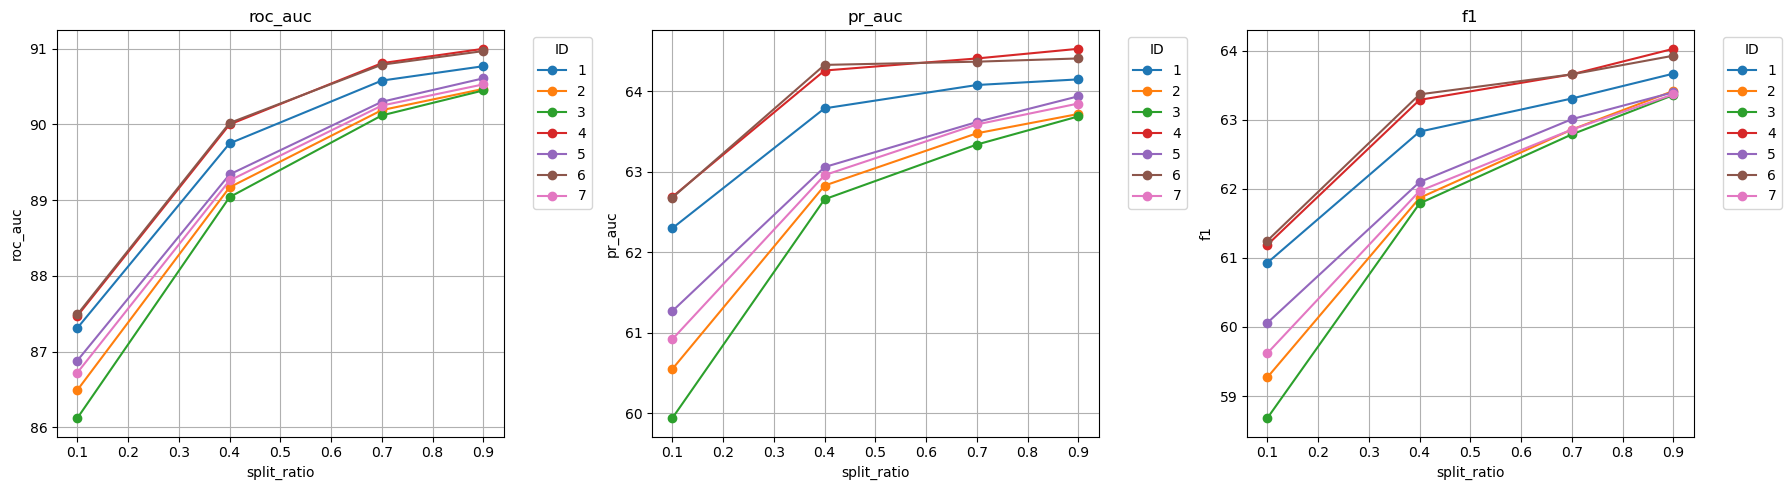

========= 合法参数编号对应表 =========
ID 1: (h=11, gamma=3, alpha=30)
ID 2: (h=11, gamma=3, alpha=50)
ID 3: (h=11, gamma=3, alpha=80)
ID 4: (h=11, gamma=4, alpha=50)
ID 5: (h=11, gamma=4, alpha=80)
ID 6: (h=13, gamma=3, alpha=50)
ID 7: (h=13, gamma=3, alpha=80)


In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# === 读取数据 ===
csv_path = "./results/icews18_grid_result.csv"
df = pd.read_csv(csv_path)

# === 准备数据 ===
metrics = ["roc_auc", "pr_auc", "f1"]
ratios = sorted(df["split_ratio"].unique())

# 只保留合法组合的数据
df_legal = df[df.apply(lambda row: (row["h"], row["gamma"], row["alpha"]) in legal_overall, axis=1)]

# === 绘图 ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for idx_metric, metric in enumerate(metrics):
    ax = axes[idx_metric]
    for i, (h, gamma, alpha) in enumerate(legal_overall, start=1):
        subdf = df_legal[
            (df_legal["h"] == h) &
            (df_legal["gamma"] == gamma) &
            (df_legal["alpha"] == alpha)
        ].sort_values("split_ratio")

        ax.plot(
            subdf["split_ratio"],
            subdf[metric],
            marker="o",
            label=f"{i}"  # 只显示编号
        )
    ax.set_title(metric)
    ax.set_xlabel("split_ratio")
    ax.set_ylabel(metric)
    ax.grid(True)
    ax.legend(title="ID", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

# === 打印编号对应表 ===
print("========= 合法参数编号对应表 =========")
for i, (h, gamma, alpha) in enumerate(legal_overall, start=1):
    print(f"ID {i}: (h={h}, gamma={gamma}, alpha={alpha})")


========= 帕累托最优参数 (ratio=0.9) =========
ID 1: (h=15.0, gamma=5.0, alpha=10.0) roc_auc=93.020, pr_auc=65.250, f1=67.160
ID 2: (h=13.0, gamma=6.0, alpha=10.0) roc_auc=92.970, pr_auc=65.830, f1=67.120
ID 3: (h=15.0, gamma=6.0, alpha=15.0) roc_auc=92.970, pr_auc=65.710, f1=67.160
ID 4: (h=15.0, gamma=6.0, alpha=30.0) roc_auc=92.920, pr_auc=65.680, f1=67.250
ID 5: (h=13.0, gamma=6.0, alpha=15.0) roc_auc=92.880, pr_auc=66.010, f1=67.150
ID 6: (h=11.0, gamma=6.0, alpha=10.0) roc_auc=92.680, pr_auc=66.150, f1=66.870
ID 7: (h=11.0, gamma=6.0, alpha=20.0) roc_auc=92.460, pr_auc=66.210, f1=66.590
ID 8: (h=11.0, gamma=5.0, alpha=20.0) roc_auc=92.420, pr_auc=66.490, f1=66.260
ID 9: (h=11.0, gamma=6.0, alpha=30.0) roc_auc=92.320, pr_auc=66.250, f1=66.290


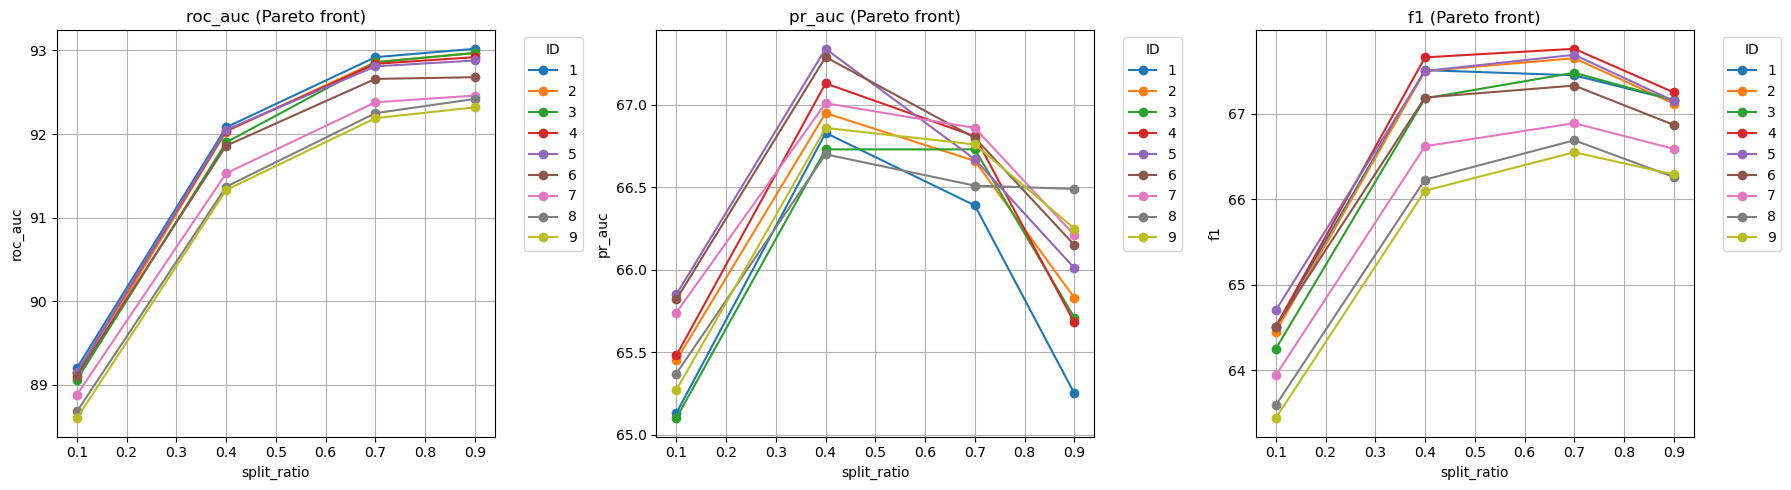


========= 帕累托最优编号对应表 =========
ID 1: (h=15.0, gamma=5.0, alpha=10.0)
ID 2: (h=13.0, gamma=6.0, alpha=10.0)
ID 3: (h=15.0, gamma=6.0, alpha=15.0)
ID 4: (h=15.0, gamma=6.0, alpha=30.0)
ID 5: (h=13.0, gamma=6.0, alpha=15.0)
ID 6: (h=11.0, gamma=6.0, alpha=10.0)
ID 7: (h=11.0, gamma=6.0, alpha=20.0)
ID 8: (h=11.0, gamma=5.0, alpha=20.0)
ID 9: (h=11.0, gamma=6.0, alpha=30.0)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# === 读取 CSV 结果 ===
csv_path = "./results/icews18_grid_result.csv"
df = pd.read_csv(csv_path)
for col in ["roc_auc", "pr_auc", "f1"]:
    df[col] = df[col].astype(float)

# === 选取 ratio = 0.9 的结果 ===
df_final = df[df["split_ratio"] == 0.9].copy()

# === 帕累托最优集判断函数 ===
def is_pareto_efficient(costs):
    """
    输入: ndarray [n, m]，每行是一个样本（m维指标）
    输出: bool 数组，True 表示该点是帕累托最优
    """
    import numpy as np
    costs = np.array(costs)
    n_points = costs.shape[0]
    is_efficient = np.ones(n_points, dtype=bool)
    for i in range(n_points):
        if is_efficient[i]:
            # 任何同时 >= 且至少有一个 > 的点会被 dominated
            dominated = np.all(costs <= costs[i], axis=1) & np.any(costs < costs[i], axis=1)
            is_efficient[dominated] = False
    return is_efficient

# === 计算帕累托最优组合 ===
costs = df_final[["roc_auc", "pr_auc", "f1"]].values
efficient_mask = is_pareto_efficient(costs)
pareto_df = df_final[efficient_mask].sort_values(["roc_auc", "pr_auc", "f1"], ascending=False).reset_index(drop=True)

# === 输出帕累托最优参数 ===
print("========= 帕累托最优参数 (ratio=0.9) =========")
for i, row in pareto_df.iterrows():
    print(f"ID {i+1}: (h={row.h}, gamma={row.gamma}, alpha={row.alpha}) "
          f"roc_auc={row.roc_auc:.3f}, pr_auc={row.pr_auc:.3f}, f1={row.f1:.3f}")

# === 绘图准备 ===
metrics = ["roc_auc", "pr_auc", "f1"]
ratios = sorted(df["split_ratio"].unique())

# 只保留帕累托最优组合的完整曲线
df_pareto = df[df.apply(lambda r: (r["h"], r["gamma"], r["alpha"]) in 
                        [(x.h, x.gamma, x.alpha) for _, x in pareto_df.iterrows()], axis=1)]

# === 绘图 ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for idx_metric, metric in enumerate(metrics):
    ax = axes[idx_metric]
    for i, (_, row) in enumerate(pareto_df.iterrows(), start=1):
        subdf = df_pareto[
            (df_pareto["h"] == row.h) &
            (df_pareto["gamma"] == row.gamma) &
            (df_pareto["alpha"] == row.alpha)
        ].sort_values("split_ratio")

        ax.plot(
            subdf["split_ratio"],
            subdf[metric],
            marker="o",
            label=f"{i}"
        )

    ax.set_title(f"{metric} (Pareto front)")
    ax.set_xlabel("split_ratio")
    ax.set_ylabel(metric)
    ax.grid(True)
    ax.legend(title="ID", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

# === 打印编号对应表 ===
print("\n========= 帕累托最优编号对应表 =========")
for i, row in pareto_df.iterrows():
    print(f"ID {i+1}: (h={row.h}, gamma={row.gamma}, alpha={row.alpha})")
